In [1]:
# Problema: Decidir cuántos asientos vender ahora a tarifa baja y cuántos reservar para pasajeros de tarifa alta que aún no han llegado, sin saber cuántos realmente aparecerán.
# Las tarifas están dadas: decidimos vender ahora o conservar capacidad.

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

data_dir = Path("../data")
submission_dir = Path("../submission")
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
display(["flight.csv", "early_requests.csv", "high_fare_demand.csv"])

['flight.csv', 'early_requests.csv', 'high_fare_demand.csv']

In [2]:
# Las solicitudes tempranas preceden a toda la demanda de tarifa alta.
flight = pd.read_csv(data_dir / "flight.csv")
requests = pd.read_csv(data_dir / "early_requests.csv").sort_values("arrival_order")
demand = pd.read_csv(data_dir / "high_fare_demand.csv")
display(flight, requests, demand)

,flight_id,capacity,low_fare,high_fare
0,F001,20,100,300


,request_id,arrival_order
0,R01,1
1,R02,2
2,R03,3
3,R04,4
4,R05,5
5,R06,6
6,R07,7
7,R08,8
8,R09,9
9,R10,10


,scenario_id,high_fare_demand,probability
0,low,4,0.3
1,medium,8,0.5
2,high,12,0.2


In [3]:
# Cada aceptación consume un asiento; no hay cancelaciones ni sobreventa.
capacity = int(flight.loc[0, "capacity"])
low_fare = float(flight.loc[0, "low_fare"])
high_fare = float(flight.loc[0, "high_fare"])
assert len(flight) == 1 and capacity == 20
assert requests.request_id.is_unique and requests.arrival_order.tolist() == list(
    range(1, 21)
)
assert not requests.isna().any().any() and not demand.isna().any().any()
assert demand.scenario_id.is_unique and demand.high_fare_demand.ge(0).all()
assert demand.probability.ge(0).all() and np.isclose(demand.probability.sum(), 1)
assert 0 < low_fare < high_fare
display(
    pd.Series(
        {"capacidad": capacity, "tarifa_baja": low_fare, "tarifa_alta": high_fare}
    )
)

capacidad       20.0
tarifa_baja    100.0
tarifa_alta    300.0
dtype: float64

In [4]:
# Política ingenua: cualquier ingreso positivo parece conveniente.
remaining = capacity
revenue = 0.0
naive_rows = []
for request in requests.itertuples(index=False):
    before = remaining
    decision = "accept" if remaining > 0 else "reject"
    if decision == "accept":
        remaining -= 1
        revenue += low_fare
    naive_rows.append(
        [
            request.request_id,
            request.arrival_order,
            before,
            decision,
            remaining,
            revenue,
        ]
    )
decision_columns = [
    "request_id",
    "arrival_order",
    "capacity_before",
    "decision",
    "capacity_after",
    "cumulative_low_fare_revenue",
]
naive = pd.DataFrame(naive_rows, columns=decision_columns)
display(naive)

,request_id,arrival_order,capacity_before,decision,capacity_after,cumulative_low_fare_revenue
0,R01,1,20,accept,19,100.0
1,R02,2,19,accept,18,200.0
2,R03,3,18,accept,17,300.0
3,R04,4,17,accept,16,400.0
4,R05,5,16,accept,15,500.0
5,R06,6,15,accept,14,600.0
6,R07,7,14,accept,13,700.0
7,R08,8,13,accept,12,800.0
8,R09,9,12,accept,11,900.0
9,R10,10,11,accept,10,1000.0


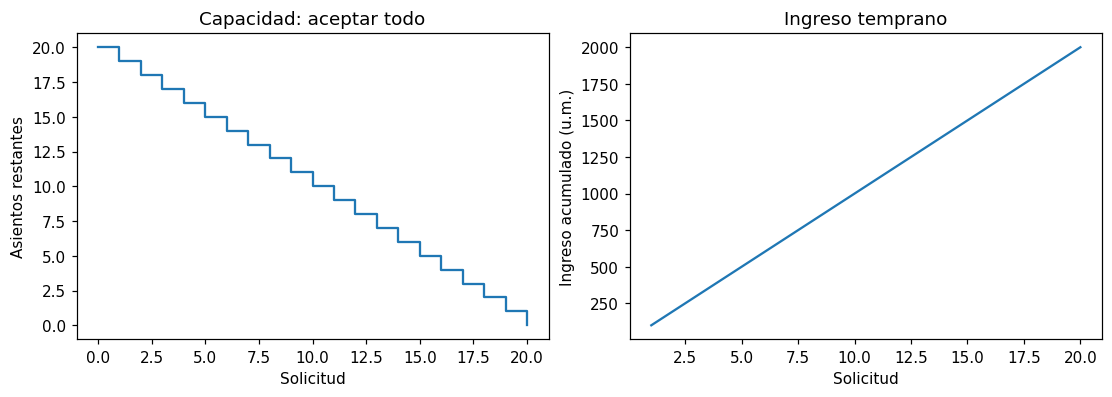

In [5]:
# El ingreso temprano aumenta mientras desaparecen las oportunidades posteriores.
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), layout="constrained")
axes[0].step(
    [0] + naive.arrival_order.tolist(),
    [capacity] + naive.capacity_after.tolist(),
    where="post",
)
axes[0].set(
    xlabel="Solicitud", ylabel="Asientos restantes", title="Capacidad: aceptar todo"
)
axes[1].plot(naive.arrival_order, naive.cumulative_low_fare_revenue)
axes[1].set(
    xlabel="Solicitud", ylabel="Ingreso acumulado (u.m.)", title="Ingreso temprano"
)
plt.show()

In [6]:
# La demanda posterior ofrece más, pero ya no quedan asientos.
naive_scenarios = demand.copy()
naive_scenarios["accepted_high_fare"] = np.minimum(demand.high_fare_demand, remaining)
naive_scenarios["rejected_high_fare"] = (
    demand.high_fare_demand - naive_scenarios.accepted_high_fare
)
naive_scenarios["total_revenue"] = (
    revenue + high_fare * naive_scenarios.accepted_high_fare
)
display(naive_scenarios)

,scenario_id,high_fare_demand,probability,accepted_high_fare,rejected_high_fare,total_revenue
0,low,4,0.3,0,4,2000.0
1,medium,8,0.5,0,8,2000.0
2,high,12,0.2,0,12,2000.0


In [7]:
# Una ilustración por escenario no sustituye una evaluación bajo incertidumbre.
medium_demand = int(demand.set_index("scenario_id").loc["medium", "high_fare_demand"])
one_seat_example = pd.DataFrame({"protected_seats": [0, 1]})
one_seat_example["total_revenue_medium"] = (
    capacity - one_seat_example.protected_seats
) * low_fare + np.minimum(one_seat_example.protected_seats, medium_demand) * high_fare
display(one_seat_example)

,protected_seats,total_revenue_medium
0,0,2000.0
1,1,2200.0


In [8]:
# Solo vendemos el menor valor entre demanda futura y capacidad reservada.
protected = np.arange(capacity + 1)
high_revenue_by_scenario = pd.DataFrame(
    np.minimum(protected[:, None], demand.high_fare_demand.to_numpy()[None, :])
    * high_fare,
    index=pd.Index(protected, name="protected_seats"),
    columns=demand.scenario_id,
)
display(high_revenue_by_scenario)

scenario_id,low,medium,high
protected_seats,,,
0,0.0,0.0,0.0
1,300.0,300.0,300.0
2,600.0,600.0,600.0
3,900.0,900.0,900.0
4,1200.0,1200.0,1200.0
5,1200.0,1500.0,1500.0
6,1200.0,1800.0,1800.0
7,1200.0,2100.0,2100.0
8,1200.0,2400.0,2400.0


In [9]:
# La expectativa combina futuros posibles sin elegir cuál ocurrirá.
future_value = high_revenue_by_scenario.mul(
    demand.set_index("scenario_id").probability, axis=1
).sum(axis=1)
future_value.name = "expected_high_fare_revenue"
display(future_value.loc[[0, 8, 12, 20]])

protected_seats
0        0.0
8     2040.0
12    2280.0
20    2280.0
Name: expected_high_fare_revenue, dtype: float64

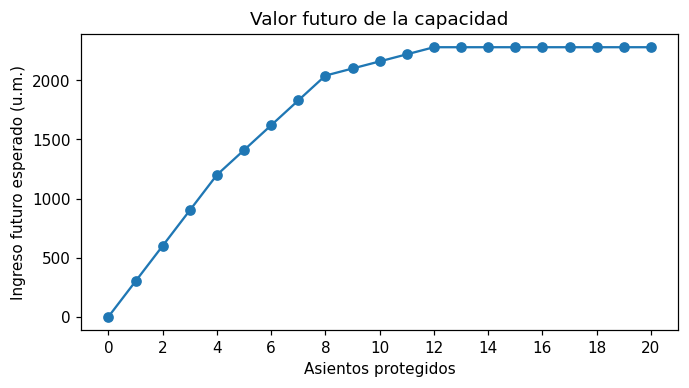

In [10]:
# Más capacidad deja de aportar cuando supera toda demanda posible.
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(protected, future_value, marker="o")
ax.set(
    xlabel="Asientos protegidos",
    ylabel="Ingreso futuro esperado (u.m.)",
    title="Valor futuro de la capacidad",
    xticks=np.arange(0, 21, 2),
)
plt.show()

In [11]:
# Valor marginal: ingreso futuro con un asiento adicional menos ingreso sin él.
marginal_value = future_value.diff()
marginal_value.name = "marginal_capacity_value"
display(pd.concat([future_value, marginal_value], axis=1))

,expected_high_fare_revenue,marginal_capacity_value
protected_seats,,
0,0.0,NaN
1,300.0,300.0
2,600.0,300.0
3,900.0,300.0
4,1200.0,300.0
5,1410.0,210.0
6,1620.0,210.0
7,1830.0,210.0
8,2040.0,210.0


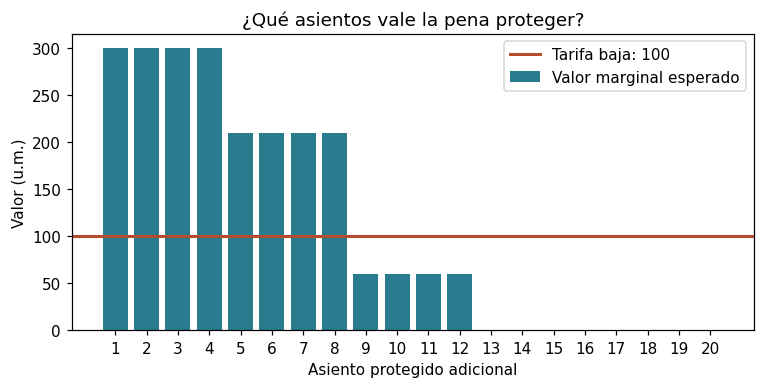

In [12]:
# Reservar también sacrifica una venta temprana de tarifa baja.
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(
    protected[1:],
    marginal_value.iloc[1:],
    color="#287c8e",
    label="Valor marginal esperado",
)
ax.axhline(low_fare, color="#b44d2d", linewidth=2, label=f"Tarifa baja: {low_fare:.0f}")
ax.set(
    xlabel="Asiento protegido adicional",
    ylabel="Valor (u.m.)",
    title="¿Qué asientos vale la pena proteger?",
    xticks=np.arange(1, 21),
)
ax.legend()
plt.show()

In [13]:
# Hay solicitudes suficientes para vender todos los asientos no protegidos.
capacity_value = pd.DataFrame(
    {
        "protected_seats": protected,
        "expected_high_fare_revenue": future_value.to_numpy(),
        "marginal_capacity_value": marginal_value.to_numpy(),
    }
)
capacity_value["early_acceptance_limit"] = capacity - protected
capacity_value["expected_low_fare_revenue"] = (
    np.minimum(len(requests), capacity_value.early_acceptance_limit) * low_fare
)
capacity_value["expected_total_revenue"] = (
    capacity_value.expected_low_fare_revenue + capacity_value.expected_high_fare_revenue
)
display(capacity_value)

,protected_seats,expected_high_fare_revenue,marginal_capacity_value,early_acceptance_limit,expected_low_fare_revenue,expected_total_revenue
0,0,0.0,NaN,20,2000.0,2000.0
1,1,300.0,300.0,19,1900.0,2200.0
2,2,600.0,300.0,18,1800.0,2400.0
3,3,900.0,300.0,17,1700.0,2600.0
4,4,1200.0,300.0,16,1600.0,2800.0
5,5,1410.0,210.0,15,1500.0,2910.0
6,6,1620.0,210.0,14,1400.0,3020.0
7,7,1830.0,210.0,13,1300.0,3130.0
8,8,2040.0,210.0,12,1200.0,3240.0
9,9,2100.0,60.0,11,1100.0,3200.0


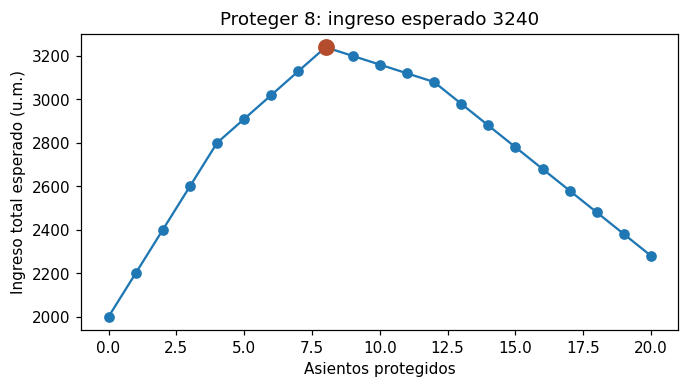

protected_seats                  8.0
expected_high_fare_revenue    2040.0
marginal_capacity_value        210.0
early_acceptance_limit          12.0
expected_low_fare_revenue     1200.0
expected_total_revenue        3240.0
Name: 8, dtype: float64

In [14]:
# Elegimos la protección por el ingreso total, no por el ingreso futuro aislado.
optimal_row = capacity_value.loc[capacity_value.expected_total_revenue.idxmax()]
optimal_protection = int(optimal_row.protected_seats)
capacity_value["is_recommended"] = capacity_value.protected_seats.eq(optimal_protection)
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(protected, capacity_value.expected_total_revenue, marker="o")
ax.scatter(
    optimal_protection,
    optimal_row.expected_total_revenue,
    color="#b44d2d",
    s=100,
    zorder=3,
)
ax.set(
    xlabel="Asientos protegidos",
    ylabel="Ingreso total esperado (u.m.)",
    title=f"Proteger {optimal_protection}: ingreso esperado {optimal_row.expected_total_revenue:.0f}",
)
plt.show()
display(optimal_row)

In [15]:
# Con nueve asientos conviene vender uno; con ocho conviene conservarlo.
acceptance_limit = capacity - optimal_protection
display(pd.Series({"limite_aceptacion_temprana": acceptance_limit}))
display(marginal_value.loc[[optimal_protection, optimal_protection + 1]])

limite_aceptacion_temprana    12
dtype: int64

protected_seats
8    210.0
9     60.0
Name: marginal_capacity_value, dtype: float64

In [16]:
# Solicitud → capacidad → valor futuro sacrificado → aceptar o rechazar.
remaining = capacity
revenue = 0.0
recommended_rows = []
for request in requests.itertuples(index=False):
    before = remaining
    opportunity = (
        future_value.loc[before] - future_value.loc[before - 1]
        if before > 0
        else np.nan
    )
    decision = "accept" if before > 0 and low_fare >= opportunity else "reject"
    if decision == "accept":
        remaining -= 1
        revenue += low_fare
    recommended_rows.append(
        [
            request.request_id,
            request.arrival_order,
            before,
            decision,
            remaining,
            revenue,
            opportunity,
        ]
    )
recommended = pd.DataFrame(
    recommended_rows, columns=decision_columns + ["opportunity_cost"]
)
display(recommended)

,request_id,arrival_order,capacity_before,decision,capacity_after,cumulative_low_fare_revenue,opportunity_cost
0,R01,1,20,accept,19,100.0,0.0
1,R02,2,19,accept,18,200.0,0.0
2,R03,3,18,accept,17,300.0,0.0
3,R04,4,17,accept,16,400.0,0.0
4,R05,5,16,accept,15,500.0,0.0
5,R06,6,15,accept,14,600.0,0.0
6,R07,7,14,accept,13,700.0,0.0
7,R08,8,13,accept,12,800.0,0.0
8,R09,9,12,accept,11,900.0,60.0
9,R10,10,11,accept,10,1000.0,60.0


In [17]:
# La misma tarifa conduce a decisiones distintas cuando cambia la escasez.
boundary = recommended[recommended.request_id.isin(["R12", "R13"])].copy()
boundary["offered_fare"] = low_fare
display(
    boundary[
        [
            "request_id",
            "capacity_before",
            "offered_fare",
            "opportunity_cost",
            "decision",
            "capacity_after",
        ]
    ]
)

,request_id,capacity_before,offered_fare,opportunity_cost,decision,capacity_after
11,R12,9,100.0,60.0,accept,8
12,R13,8,100.0,210.0,reject,8


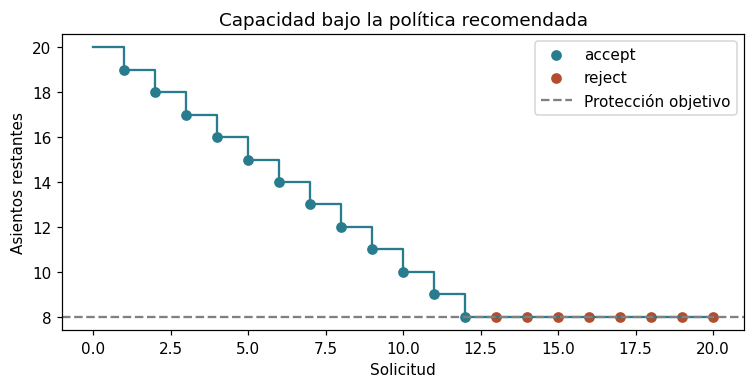

In [18]:
# Rechazar conserva capacidad para oportunidades que valen más en expectativa.
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.step(
    [0] + recommended.arrival_order.tolist(),
    [capacity] + recommended.capacity_after.tolist(),
    where="post",
    color="#287c8e",
)
for decision, color in [("accept", "#287c8e"), ("reject", "#b44d2d")]:
    part = recommended[recommended.decision == decision]
    ax.scatter(part.arrival_order, part.capacity_after, color=color, label=decision)
ax.axhline(
    optimal_protection, color="gray", linestyle="--", label="Protección objetivo"
)
ax.set(
    xlabel="Solicitud",
    ylabel="Asientos restantes",
    title="Capacidad bajo la política recomendada",
)
ax.legend()
plt.show()

In [19]:
# La política ingenua ignora este costo; el ingreso temprano no es el ingreso total.
naive["opportunity_cost"] = naive.capacity_before.map(marginal_value)
early_summary = pd.DataFrame(
    [
        [
            "accept_all",
            naive.decision.eq("accept").sum(),
            naive.capacity_after.iloc[-1],
            naive.cumulative_low_fare_revenue.iloc[-1],
        ],
        [
            "recommended",
            recommended.decision.eq("accept").sum(),
            recommended.capacity_after.iloc[-1],
            recommended.cumulative_low_fare_revenue.iloc[-1],
        ],
    ],
    columns=[
        "policy",
        "accepted_early_requests",
        "protected_seats",
        "low_fare_revenue",
    ],
)
display(
    early_summary,
    naive.loc[
        naive.request_id.isin(["R12", "R13"]),
        ["request_id", "opportunity_cost", "decision"],
    ],
)

,policy,accepted_early_requests,protected_seats,low_fare_revenue
0,accept_all,20,0,2000.0
1,recommended,12,8,1200.0


,request_id,opportunity_cost,decision
11,R12,60.0,accept
12,R13,210.0,accept


In [20]:
# Comparamos las políticas ante los mismos futuros, sin simular un resultado observado.
policy_scenarios = early_summary.merge(demand, how="cross")
policy_scenarios["accepted_high_fare"] = np.minimum(
    policy_scenarios.protected_seats, policy_scenarios.high_fare_demand
)
policy_scenarios["total_revenue"] = (
    policy_scenarios.low_fare_revenue + policy_scenarios.accepted_high_fare * high_fare
)
display(
    policy_scenarios[["policy", "scenario_id", "accepted_high_fare", "total_revenue"]]
)

,policy,scenario_id,accepted_high_fare,total_revenue
0,accept_all,low,0,2000.0
1,accept_all,medium,0,2000.0
2,accept_all,high,0,2000.0
3,recommended,low,4,2400.0
4,recommended,medium,8,3600.0
5,recommended,high,8,3600.0


In [21]:
# Proteger doce gana más con demanda alta, pero sacrifica ventas en otros escenarios.
excess_protection = 12
excess = demand.assign(
    policy="protect_12",
    protected_seats=excess_protection,
    accepted_early_requests=min(len(requests), capacity - excess_protection),
)
excess["low_fare_revenue"] = excess.accepted_early_requests * low_fare
excess["accepted_high_fare"] = np.minimum(
    excess.protected_seats, excess.high_fare_demand
)
excess["total_revenue"] = (
    excess.low_fare_revenue + excess.accepted_high_fare * high_fare
)
display(excess)

,scenario_id,high_fare_demand,probability,policy,protected_seats,accepted_early_requests,low_fare_revenue,accepted_high_fare,total_revenue
0,low,4,0.3,protect_12,12,8,800.0,4,2000.0
1,medium,8,0.5,protect_12,12,8,800.0,8,3200.0
2,high,12,0.2,protect_12,12,8,800.0,12,4400.0


In [22]:
# Ventas perdidas y asientos vacíos revelan consecuencias diferentes.
scenario_results = pd.concat([policy_scenarios, excess], ignore_index=True)
scenario_results["rejected_high_fare"] = (
    scenario_results.high_fare_demand - scenario_results.accepted_high_fare
)
scenario_results["empty_seats"] = (
    capacity
    - scenario_results.accepted_early_requests
    - scenario_results.accepted_high_fare
)
scenario_results["high_fare_revenue"] = scenario_results.accepted_high_fare * high_fare
scenario_columns = [
    "policy",
    "scenario_id",
    "probability",
    "protected_seats",
    "accepted_early_requests",
    "high_fare_demand",
    "accepted_high_fare",
    "rejected_high_fare",
    "empty_seats",
    "low_fare_revenue",
    "high_fare_revenue",
    "total_revenue",
]
scenario_results = scenario_results[scenario_columns]
display(scenario_results)

,policy,scenario_id,probability,protected_seats,accepted_early_requests,high_fare_demand,accepted_high_fare,rejected_high_fare,empty_seats,low_fare_revenue,high_fare_revenue,total_revenue
0,accept_all,low,0.3,0,20,4,0,4,0,2000.0,0.0,2000.0
1,accept_all,medium,0.5,0,20,8,0,8,0,2000.0,0.0,2000.0
2,accept_all,high,0.2,0,20,12,0,12,0,2000.0,0.0,2000.0
3,recommended,low,0.3,8,12,4,4,0,4,1200.0,1200.0,2400.0
4,recommended,medium,0.5,8,12,8,8,0,0,1200.0,2400.0,3600.0
5,recommended,high,0.2,8,12,12,8,4,0,1200.0,2400.0,3600.0
6,protect_12,low,0.3,12,8,4,4,0,8,800.0,1200.0,2000.0
7,protect_12,medium,0.5,12,8,8,8,0,4,800.0,2400.0,3200.0
8,protect_12,high,0.2,12,8,12,12,0,0,800.0,3600.0,4400.0


,total_revenue,rejected_high_fare,empty_seats
policy,,,
accept_all,2000.0,7.6,0.0
recommended,3240.0,0.8,1.2
protect_12,3080.0,0.0,4.4


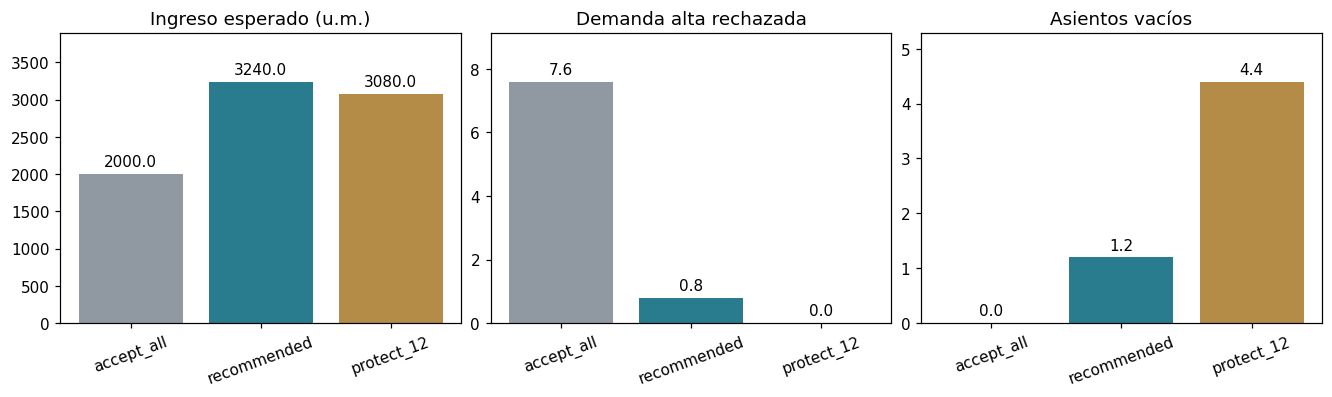

In [23]:
# Evitar toda demanda rechazada puede exigir una protección demasiado costosa.
metrics = ["total_revenue", "rejected_high_fare", "empty_seats"]
weighted = scenario_results[metrics].mul(scenario_results.probability, axis=0)
expected_metrics = weighted.groupby(scenario_results.policy, sort=False).sum()
display(expected_metrics)
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), layout="constrained")
for ax, metric, title in zip(
    axes,
    metrics,
    ["Ingreso esperado (u.m.)", "Demanda alta rechazada", "Asientos vacíos"],
):
    bars = ax.bar(
        expected_metrics.index,
        expected_metrics[metric],
        color=["#9099a2", "#287c8e", "#b48b47"],
    )
    ax.bar_label(bars, fmt="%.1f", padding=3)
    ax.set(title=title, ylim=(0, expected_metrics[metric].max() * 1.2))
    ax.tick_params(axis="x", rotation=20)
plt.show()

In [24]:
# Cambia la creencia sobre demanda, no las tarifas ni el escenario base.
variant_probabilities = pd.Series({"low": 0.20, "medium": 0.40, "high": 0.40})
variant_future = high_revenue_by_scenario.mul(variant_probabilities, axis=1).sum(axis=1)
variant_total = capacity_value.expected_low_fare_revenue.to_numpy() + variant_future
variant_protection = int(variant_total.idxmax())
display(
    variant_probabilities,
    pd.Series(
        {
            "proteccion_variante": variant_protection,
            "valor_marginal_asiento_9": variant_future.diff().loc[9],
        }
    ),
)

low       0.2
medium    0.4
high      0.4
dtype: float64

proteccion_variante          12.0
valor_marginal_asiento_9    120.0
dtype: float64

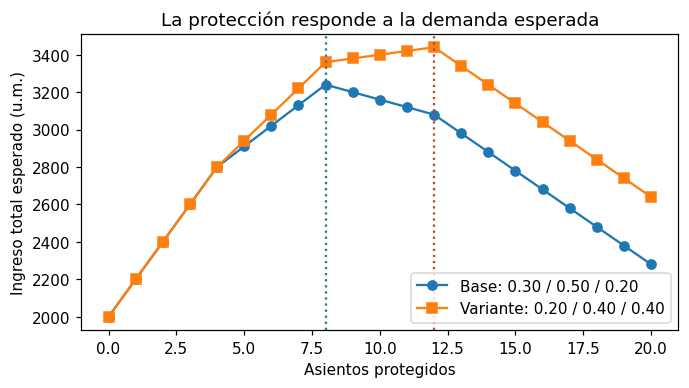

In [25]:
# La sensibilidad es exploratoria; los artefactos conservarán el escenario base.
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(
    protected,
    capacity_value.expected_total_revenue,
    marker="o",
    label="Base: 0.30 / 0.50 / 0.20",
)
ax.plot(protected, variant_total, marker="s", label="Variante: 0.20 / 0.40 / 0.40")
ax.axvline(optimal_protection, color="#287c8e", linestyle=":")
ax.axvline(variant_protection, color="#b44d2d", linestyle=":")
ax.set(
    xlabel="Asientos protegidos",
    ylabel="Ingreso total esperado (u.m.)",
    title="La protección responde a la demanda esperada",
)
ax.legend()
plt.show()

In [26]:
# Tres tablas separan valor económico, decisiones e impactos por escenario.
naive_final = naive.assign(
    policy="accept_all", offered_fare=low_fare, protection_target=0
)
recommended_final = recommended.assign(
    policy="recommended", offered_fare=low_fare, protection_target=optimal_protection
)
booking_columns = [
    "policy",
    "request_id",
    "arrival_order",
    "capacity_before",
    "offered_fare",
    "opportunity_cost",
    "decision",
    "capacity_after",
    "cumulative_low_fare_revenue",
    "protection_target",
]
booking_decisions = pd.concat(
    [naive_final[booking_columns], recommended_final[booking_columns]],
    ignore_index=True,
)
display(capacity_value.head(), booking_decisions.head(), scenario_results.head())
print(
    f"Filas: capacidad={len(capacity_value)}, decisiones={len(booking_decisions)}, escenarios={len(scenario_results)}"
)

,protected_seats,expected_high_fare_revenue,marginal_capacity_value,early_acceptance_limit,expected_low_fare_revenue,expected_total_revenue,is_recommended
0,0,0.0,NaN,20,2000.0,2000.0,False
1,1,300.0,300.0,19,1900.0,2200.0,False
2,2,600.0,300.0,18,1800.0,2400.0,False
3,3,900.0,300.0,17,1700.0,2600.0,False
4,4,1200.0,300.0,16,1600.0,2800.0,False


,policy,request_id,arrival_order,capacity_before,offered_fare,opportunity_cost,decision,capacity_after,cumulative_low_fare_revenue,protection_target
0,accept_all,R01,1,20,100.0,0.0,accept,19,100.0,0
1,accept_all,R02,2,19,100.0,0.0,accept,18,200.0,0
2,accept_all,R03,3,18,100.0,0.0,accept,17,300.0,0
3,accept_all,R04,4,17,100.0,0.0,accept,16,400.0,0
4,accept_all,R05,5,16,100.0,0.0,accept,15,500.0,0


,policy,scenario_id,probability,protected_seats,accepted_early_requests,high_fare_demand,accepted_high_fare,rejected_high_fare,empty_seats,low_fare_revenue,high_fare_revenue,total_revenue
0,accept_all,low,0.3,0,20,4,0,4,0,2000.0,0.0,2000.0
1,accept_all,medium,0.5,0,20,8,0,8,0,2000.0,0.0,2000.0
2,accept_all,high,0.2,0,20,12,0,12,0,2000.0,0.0,2000.0
3,recommended,low,0.3,8,12,4,4,0,4,1200.0,1200.0,2400.0
4,recommended,medium,0.5,8,12,8,8,0,0,1200.0,2400.0,3600.0


Filas: capacidad=21, decisiones=40, escenarios=9


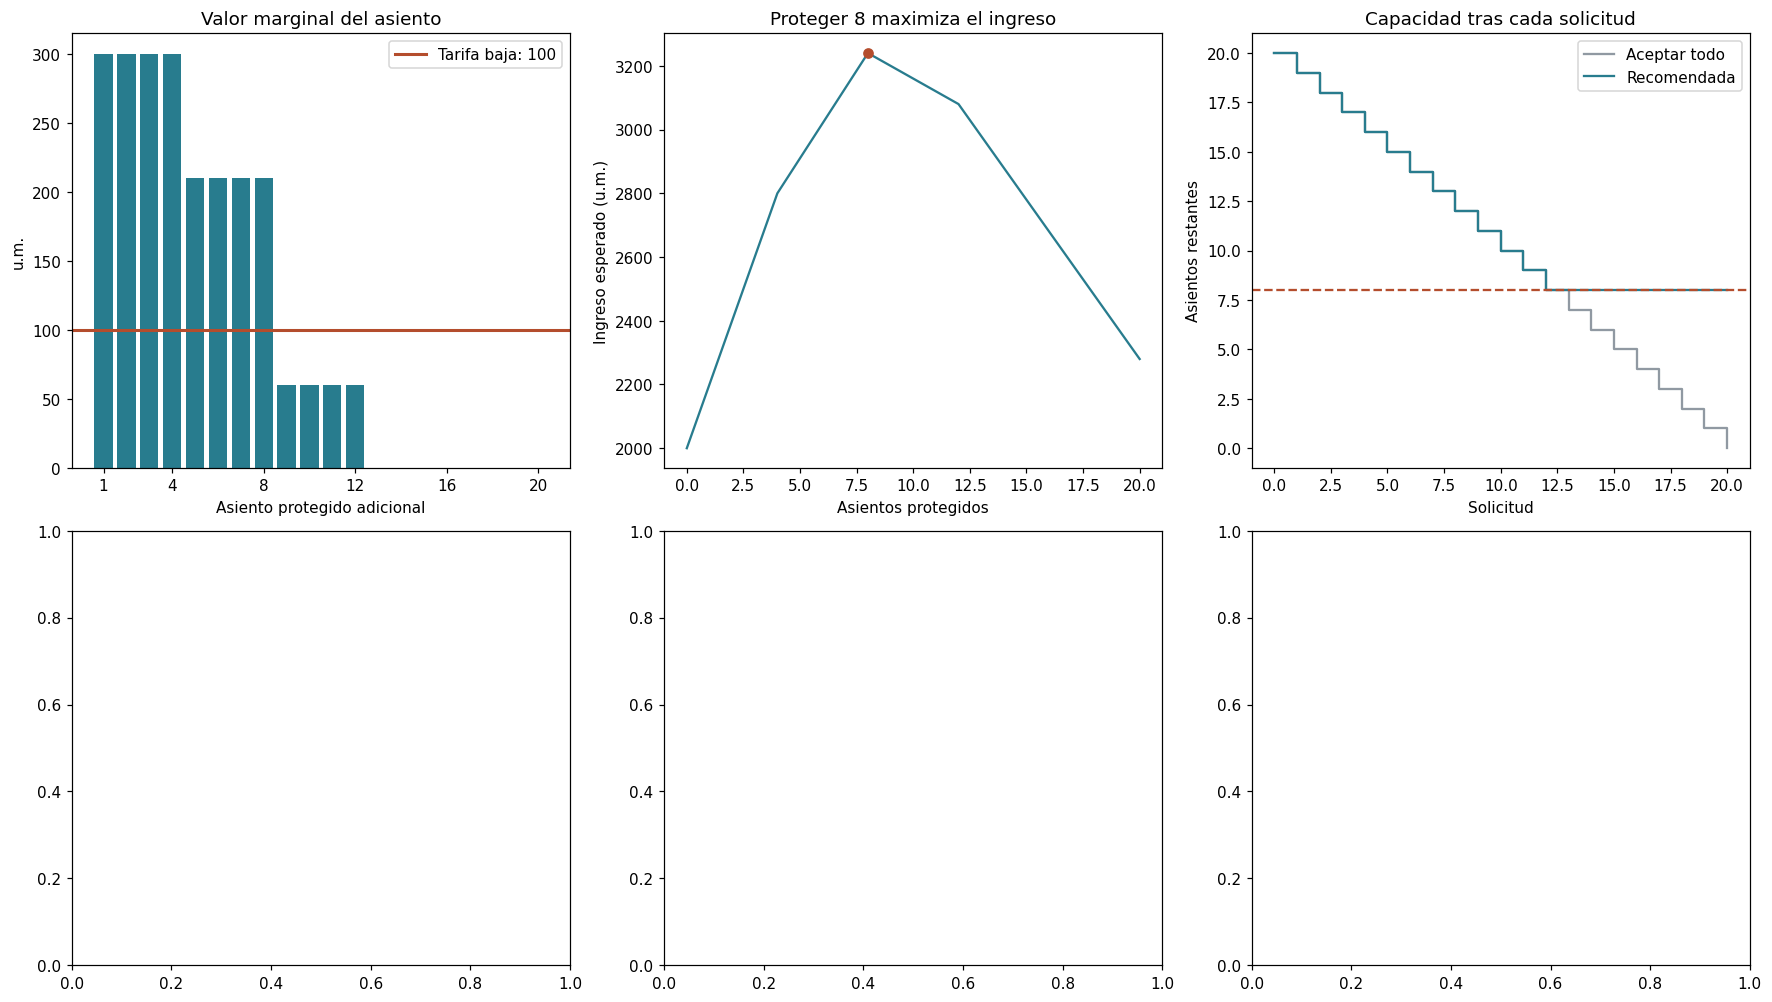

In [27]:
# El cockpit conecta valor marginal, protección y operación solicitud por solicitud.
cockpit_fig, cockpit_axes = plt.subplots(2, 3, figsize=(16, 9), layout="constrained")
ax = cockpit_axes[0, 0]
ax.bar(protected[1:], marginal_value.iloc[1:], color="#287c8e")
ax.axhline(low_fare, color="#b44d2d", linewidth=2, label=f"Tarifa baja: {low_fare:.0f}")
ax.set(
    title="Valor marginal del asiento",
    xlabel="Asiento protegido adicional",
    ylabel="u.m.",
    xticks=[1, 4, 8, 12, 16, 20],
)
ax.legend()
ax = cockpit_axes[0, 1]
ax.plot(protected, capacity_value.expected_total_revenue, color="#287c8e")
ax.scatter(
    optimal_protection, optimal_row.expected_total_revenue, color="#b44d2d", zorder=3
)
ax.set(
    title=f"Proteger {optimal_protection} maximiza el ingreso",
    xlabel="Asientos protegidos",
    ylabel="Ingreso esperado (u.m.)",
)
ax = cockpit_axes[0, 2]
for table, label, color in [
    (naive, "Aceptar todo", "#9099a2"),
    (recommended, "Recomendada", "#287c8e"),
]:
    ax.step(
        [0] + table.arrival_order.tolist(),
        [capacity] + table.capacity_after.tolist(),
        where="post",
        label=label,
        color=color,
    )
ax.axhline(optimal_protection, color="#b44d2d", linestyle="--")
ax.set(
    title="Capacidad tras cada solicitud",
    xlabel="Solicitud",
    ylabel="Asientos restantes",
)
ax.legend()
plt.show()

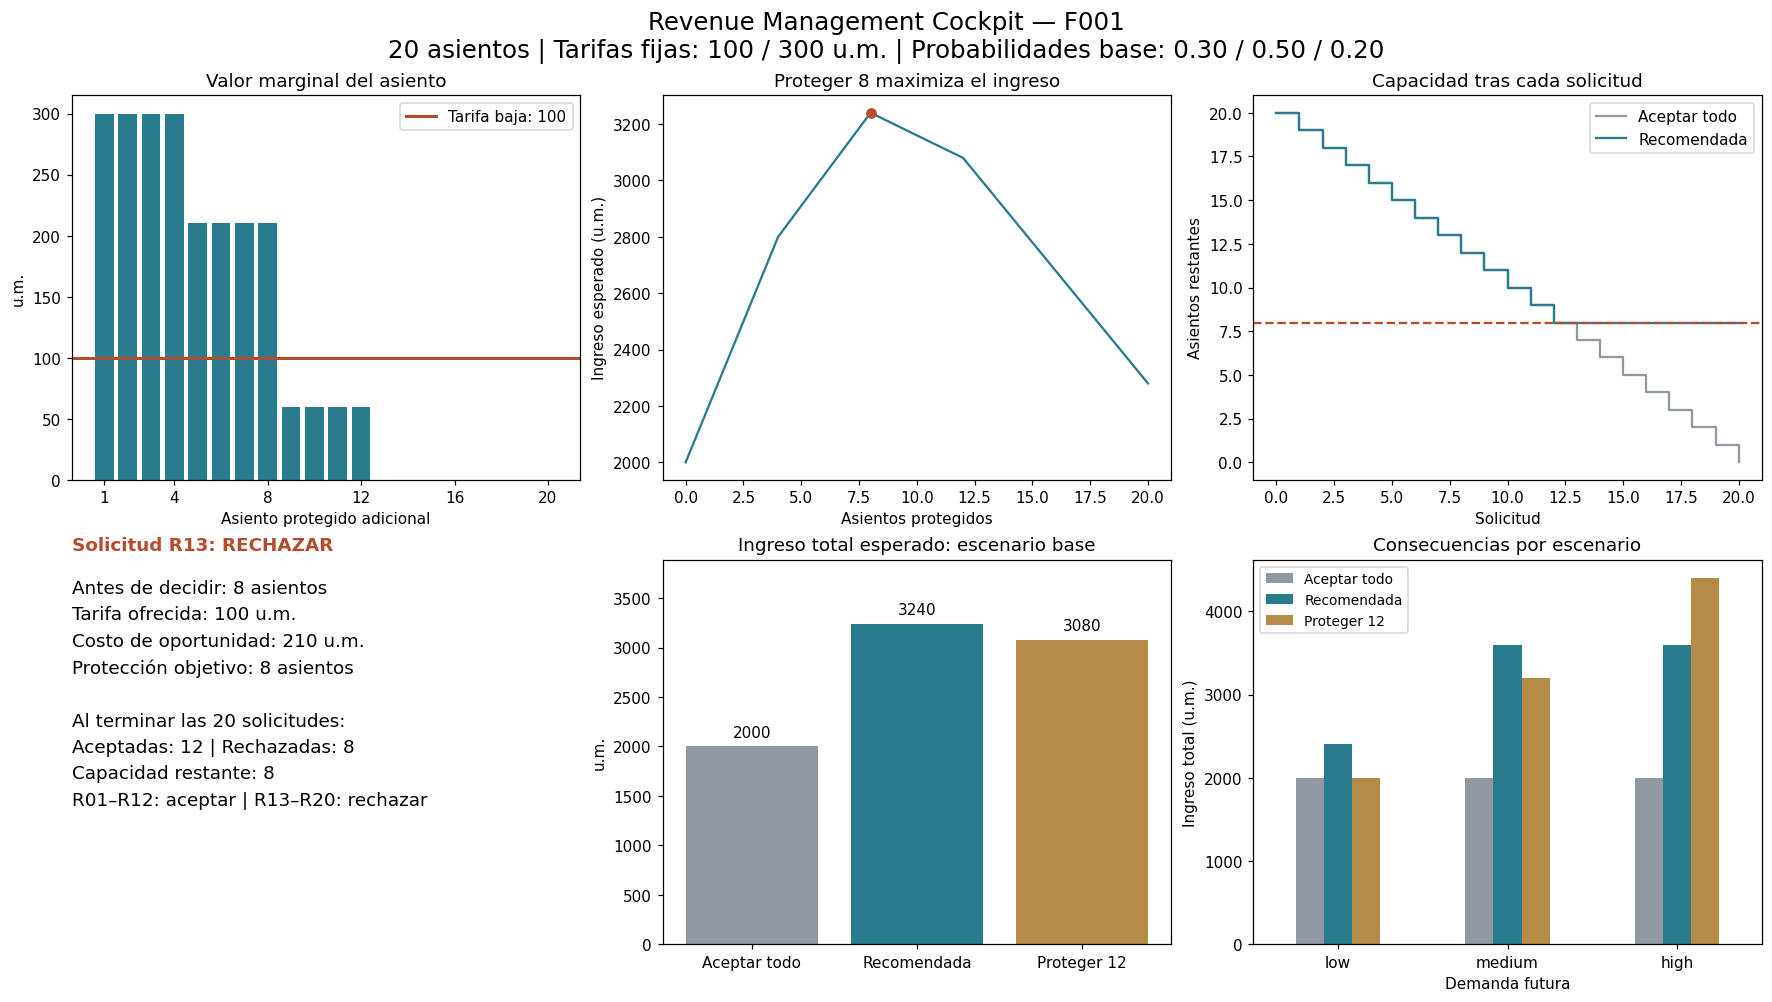

In [28]:
# R13 muestra un estado de decisión; el resumen muestra el final de la etapa temprana.
r13 = recommended.set_index("request_id").loc["R13"]
ax = cockpit_axes[1, 0]
ax.axis("off")
ax.set_title("Solicitud R13: RECHAZAR", loc="left", color="#b44d2d", weight="bold")
summary_text = f'Antes de decidir: {r13.capacity_before} asientos\nTarifa ofrecida: {low_fare:.0f} u.m.\nCosto de oportunidad: {r13.opportunity_cost:.0f} u.m.\nProtección objetivo: {optimal_protection} asientos\n\nAl terminar las 20 solicitudes:\nAceptadas: {recommended.decision.eq("accept").sum()} | Rechazadas: {recommended.decision.eq("reject").sum()}\nCapacidad restante: {recommended.capacity_after.iloc[-1]}\nR01–R12: aceptar | R13–R20: rechazar'
ax.text(
    0,
    0.95,
    summary_text,
    transform=ax.transAxes,
    va="top",
    fontsize=12,
    linespacing=1.6,
)
ax = cockpit_axes[1, 1]
labels = ["Aceptar todo", "Recomendada", "Proteger 12"]
bars = ax.bar(
    labels, expected_metrics.total_revenue, color=["#9099a2", "#287c8e", "#b48b47"]
)
ax.bar_label(bars, fmt="%.0f", padding=4)
ax.set(
    title="Ingreso total esperado: escenario base",
    ylabel="u.m.",
    ylim=(0, expected_metrics.total_revenue.max() * 1.2),
)
ax = cockpit_axes[1, 2]
scenario_plot = scenario_results.pivot(
    index="scenario_id", columns="policy", values="total_revenue"
).reindex(demand.scenario_id)
scenario_plot[["accept_all", "recommended", "protect_12"]].plot.bar(
    ax=ax, color=["#9099a2", "#287c8e", "#b48b47"], rot=0
)
ax.set(
    title="Consecuencias por escenario",
    xlabel="Demanda futura",
    ylabel="Ingreso total (u.m.)",
)
ax.legend(labels, fontsize=9)
cockpit_fig.suptitle(
    f'Revenue Management Cockpit — {flight.loc[0, "flight_id"]}\n20 asientos | Tarifas fijas: 100 / 300 u.m. | Probabilidades base: 0.30 / 0.50 / 0.20',
    fontsize=16,
)
display(cockpit_fig)

In [29]:
# Verificamos factibilidad, frontera operativa y consecuencias del escenario aprobado.
assert (
    len(capacity_value) == 21
    and len(booking_decisions) == 40
    and len(scenario_results) == 9
)
assert not booking_decisions.duplicated(["policy", "request_id"]).any()
assert not scenario_results.duplicated(["policy", "scenario_id"]).any()
assert optimal_protection == 8 and acceptance_limit == 12 and variant_protection == 12
assert (
    capacity_value.is_recommended.sum() == 1
    and capacity_value.expected_total_revenue.eq(
        optimal_row.expected_total_revenue
    ).sum()
    == 1
)
assert np.allclose(marginal_value.iloc[1:], [300] * 4 + [210] * 4 + [60] * 4 + [0] * 8)
assert recommended.loc[recommended.decision == "accept", "request_id"].tolist() == [
    f"R{i:02d}" for i in range(1, 13)
]
assert boundary.capacity_before.tolist() == [9, 8] and boundary.decision.tolist() == [
    "accept",
    "reject",
]
assert np.allclose(boundary.opportunity_cost, [60, 210])
assert booking_decisions.capacity_after.ge(0).all()
assert (
    (booking_decisions.capacity_before - booking_decisions.capacity_after)
    .eq(booking_decisions.decision.eq("accept").astype(int))
    .all()
)
assert np.allclose(
    scenario_results.accepted_early_requests
    + scenario_results.accepted_high_fare
    + scenario_results.empty_seats,
    capacity,
)
assert np.allclose(
    scenario_results.accepted_high_fare + scenario_results.rejected_high_fare,
    scenario_results.high_fare_demand,
)
assert np.allclose(
    scenario_results.total_revenue,
    scenario_results.accepted_early_requests * low_fare
    + scenario_results.accepted_high_fare * high_fare,
)
assert np.allclose(
    expected_metrics.loc[["recommended", "accept_all", "protect_12"], "total_revenue"],
    [3240, 2000, 3080],
)
assert np.allclose(
    expected_metrics.loc[
        ["accept_all", "recommended", "protect_12"],
        ["rejected_high_fare", "empty_seats"],
    ],
    [[7.6, 0], [0.8, 1.2], [0, 4.4]],
)
print("Verificado: proteger 8, aceptar 12; ingresos esperados 3240 / 2000 / 3080.")

Verificado: proteger 8, aceptar 12; ingresos esperados 3240 / 2000 / 3080.


In [30]:
# Exportamos resultados calculados del escenario base, no de la sensibilidad.
submission_dir.mkdir(exist_ok=True)
capacity_value.to_csv(submission_dir / "capacity_value.csv", index=False)
booking_decisions.to_csv(submission_dir / "booking_decisions.csv", index=False)
scenario_results.to_csv(submission_dir / "scenario_results.csv", index=False)
cockpit_fig.savefig(
    submission_dir / "revenue_management_cockpit.png",
    dpi=180,
    bbox_inches="tight",
    facecolor="white",
)
display(
    [
        str(submission_dir / name)
        for name in [
            "capacity_value.csv",
            "booking_decisions.csv",
            "scenario_results.csv",
            "revenue_management_cockpit.png",
        ]
    ]
)

['../submission/capacity_value.csv',
 '../submission/booking_decisions.csv',
 '../submission/scenario_results.csv',
 '../submission/revenue_management_cockpit.png']